In [ ]:
# !pip install git+https://github.com/huggingface/diffusers.git
# !pip install basicsr
# !pip install super-image
# !pip install torch
# !pip install torchvision
# !pip install scikit-image

In [1]:
import requests
from PIL import Image
from io import BytesIO
from diffusers import LDMSuperResolutionPipeline
import torch
import torch.nn as nn
import torchvision.transforms as T
import numpy as np

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [2]:
import glob
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
device

'cuda'

In [ ]:
#DATA_PATH = "/gdrive/MyDrive/Super_Resolution/Data/Test_images_2023"
#DATA_PATH = "/gdrive/MyDrive/SR_seeds/Test_images_2023"
DATA_PATH = "/content/gdrive/MyDrive/SR_seeds/Grains_(Pasynkov)"

In [5]:
all_sr_imgs = []

# LDM

In [6]:
model_id = "CompVis/ldm-super-resolution-4x-openimages"
pipeline = LDMSuperResolutionPipeline.from_pretrained(model_id)
pipeline = pipeline.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/248 [00:00<?, ?B/s]

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--CompVis--ldm-super-resolution-4x-openimages/snapshots/0b55ddf931a8e3a1b426b3a50ddcf325ff84f668/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--CompVis--ldm-super-resolution-4x-openimages/snapshots/0b55ddf931a8e3a1b426b3a50ddcf325ff84f668/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--CompVis--ldm-super-resolution-4x-openimages/snapshots/0b55ddf931a8e3a1b426b3a50ddcf325ff84f668/vqvae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--CompVis--ldm-super-resolution-4x-openimages/snapshots/0b55ddf931a8e3a1b426b3a50ddcf325ff84f668/vqvae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [7]:
transform = T.ToTensor()

In [11]:
all_sr_imgs = []
SAVE_PATH = "/content/gdrive/MyDrive/SR_seeds/LDM_(Pasynkov)/"
import os
os.makedirs(SAVE_PATH, exist_ok=True)

In [ ]:
all_orig_imgs = []
all_lr_imgs = []
for i in range(2651, 4501):
  if i % 100 == 0:
    print(i)

  img = Image.open(DATA_PATH + f"/grain_{i}.png").convert("RGB")

  all_orig_imgs.append(img)

  w, h = img.size

  lr_img = img.resize((int(w*1), int(h*1)))
  all_lr_imgs.append(lr_img)

  upscaled_image = pipeline(img, num_inference_steps=100, eta=1).images[0]
  #all_sr_imgs.append(upscaled_image)

  filename = f"{str(i).zfill(4)}.png"  # 0001.png, 0002.png ...
  upscaled_image.save(os.path.join(SAVE_PATH, filename))

  0%|          | 0/50 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 5.08 GiB. GPU 0 has a total capacity of 14.56 GiB of which 3.54 GiB is free. Including non-PyTorch memory, this process has 11.02 GiB memory in use. Of the allocated memory 4.49 GiB is allocated by PyTorch, and 6.41 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

# Evaluation

In [8]:
LR_PATH = "/content/gdrive/MyDrive/SR_seeds/Evaluation/LR/"
HR_PATH = "/content/gdrive/MyDrive/SR_seeds/Evaluation/HR/"

In [9]:
all_lr_imgs = []
all_hr_imgs = []

In [12]:
for i in range(1, 8):
    lr_img = Image.open(os.path.join(LR_PATH, f"lr_img_{i}.png")).convert("RGB")
    hr_img = Image.open(os.path.join(HR_PATH, f"hr_img_{i}.png")).convert("RGB")

    all_lr_imgs.append(lr_img)
    all_hr_imgs.append(hr_img)

In [13]:
import torch.nn.functional as F
from math import log10
from skimage.metrics import structural_similarity as ssim
import numpy as np

psnr_list = []
ssim_list = []

In [14]:
def compute_psnr(sr, hr):
    mse = F.mse_loss(sr, hr)
    if mse == 0:
        return 100
    return 10 * log10(1.0 / mse.item())


def compute_ssim(sr, hr):
    sr = sr.permute(1, 2, 0).cpu().numpy()
    hr = hr.permute(1, 2, 0).cpu().numpy()

    return ssim(sr, hr, channel_axis=2, data_range=1.0)

In [15]:
sr_results = []

In [16]:
def match_size(sr, hr):
    """
    HR to the size of SR through bilinear resize
    """
    sr_h, sr_w = sr.shape[-2], sr.shape[-1]
    hr = F.interpolate(hr.unsqueeze(0), size=(sr_h, sr_w), mode="bilinear", align_corners=False)
    return hr.squeeze(0)

In [17]:
for i in range(0, 7):
    lr_img = all_lr_imgs[i]
    hr_img = all_hr_imgs[i]

    # ===== SR inference =====
    lr_gray = lr_img.convert("RGB")

    w, h = lr_gray.size
    upscaled = lr_gray.resize((w*4, h*4))

    inp = transform(upscaled).unsqueeze(0).to(device)

    sr_img = pipeline(lr_gray, num_inference_steps=100, eta=1).images[0]

    sr_tensor = transform(sr_img.convert("RGB"))

    sr_results.append(sr_img)

    # ===== HR tensor =====
    hr_tensor = transform(hr_img.convert("RGB"))

    # ===== ALIGN SIZE (КРИТИЧНО) =====
    if hr_tensor.shape != sr_tensor.shape:
        hr_tensor = match_size(sr_tensor, hr_tensor)

    # ===== METRICS =====
    psnr_val = compute_psnr(sr_tensor, hr_tensor)
    ssim_val = compute_ssim(sr_tensor, hr_tensor)

    psnr_list.append(psnr_val)
    ssim_list.append(ssim_val)

    print(f"[{i+1}] PSNR: {psnr_val:.3f} | SSIM: {ssim_val:.4f}")

  0%|          | 0/100 [00:00<?, ?it/s]

[1] PSNR: 29.966 | SSIM: 0.8188


  0%|          | 0/100 [00:00<?, ?it/s]

[2] PSNR: 26.063 | SSIM: 0.6420


  0%|          | 0/100 [00:00<?, ?it/s]

...

[5] PSNR: 28.081 | SSIM: 0.7873


  0%|          | 0/100 [00:00<?, ?it/s]

[6] PSNR: 28.380 | SSIM: 0.7149


  0%|          | 0/100 [00:00<?, ?it/s]

[7] PSNR: 23.084 | SSIM: 0.6130


In [18]:
print("\n========== FINAL ==========")
print(f"Mean PSNR: {np.mean(psnr_list):.3f}")
print(f"Mean SSIM: {np.mean(ssim_list):.4f}")


========== FINAL ==========
Mean PSNR: 28.233
Mean SSIM: 0.7343


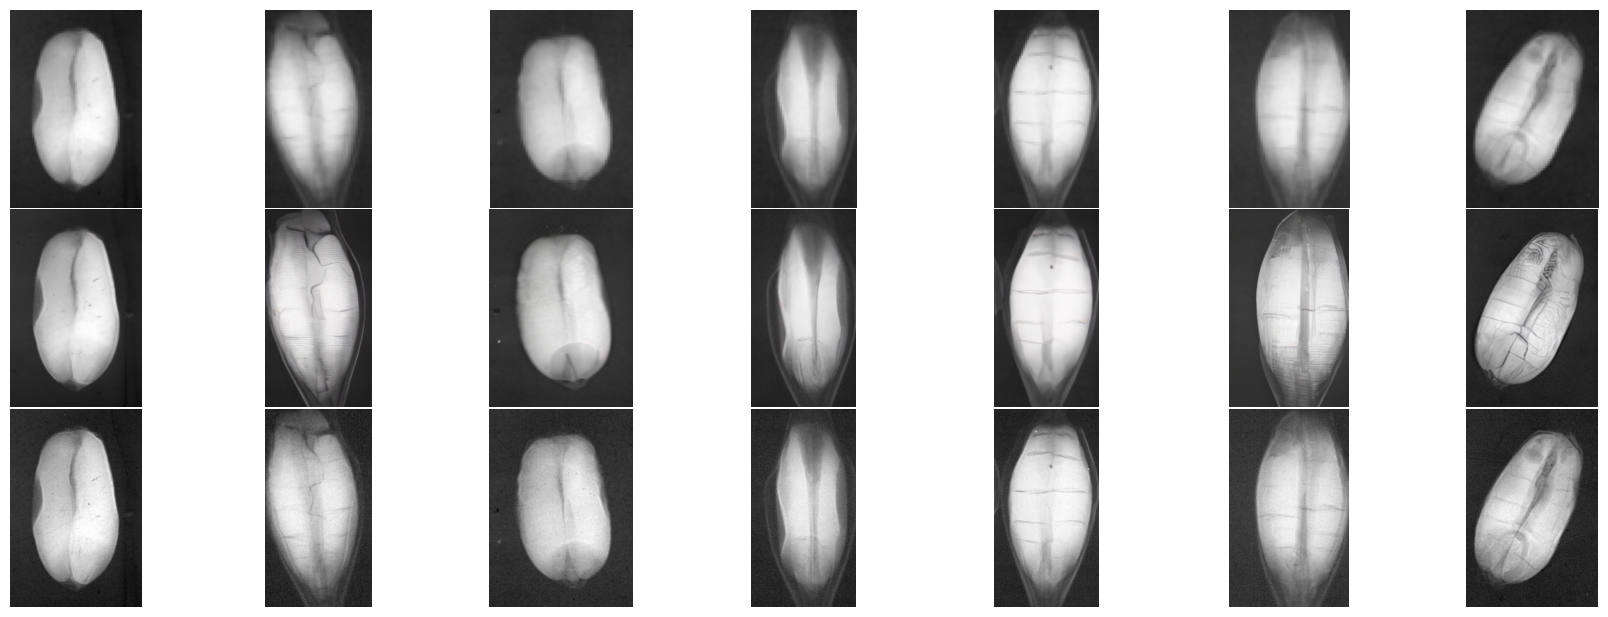

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 7, figsize=(18, 6))

plt.subplots_adjust(wspace=0.01, hspace=0.01)

for i in range(7):

    # ===== LR =====
    axes[0, i].imshow(all_lr_imgs[i])
    axes[0, i].axis("off")

    # ===== SR =====
    axes[1, i].imshow(sr_results[i].resize(all_hr_imgs[i].size), cmap="gray")
    axes[1, i].axis("off")

    # ===== HR =====
    axes[2, i].imshow(all_hr_imgs[i])
    axes[2, i].axis("off")

plt.tight_layout(pad=0.1)
plt.show()
